In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os

print(os.listdir('/content'))

['.config', 'elliptic_txs_features.csv', 'elliptic_txs_classes.csv', 'elliptic_txs_edgelist.csv', 'sample_data']


In [3]:
classes = pd.read_csv('/content/elliptic_txs_classes.csv')
edges = pd.read_csv('/content/elliptic_txs_edgelist.csv')

print("Classes shape:", classes.shape)
print("Edges shape:", edges.shape)

Classes shape: (203769, 2)
Edges shape: (234355, 2)


In [4]:
classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [5]:
print(classes.columns.tolist())

['txId', 'class']


In [6]:
print(classes['class'].value_counts())

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


In [7]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [8]:
print(edges.columns.tolist())

['txId1', 'txId2']


In [9]:
print("Number of transaction connections:", len(edges))

Number of transaction connections: 234355


In [10]:
features_sample = pd.read_csv(
    '/content/elliptic_txs_features.csv',
    nrows=5
)

print(features_sample.columns.tolist())

['230425980', '1', '-0.1714692896288031', '-0.18466755143291433', '-1.2013688016765636', '-0.12196959975910057', '-0.04387454791734898', '-0.11300200928476244', '-0.06158379407303222', '-0.16209679981659642', '-0.16793302645225652', '-0.04970696439403985', '-0.16440217329951', '-0.028741285856664783', '-0.035390552600813516', '-0.042955299258028254', '-0.013281614870058885', '-0.057194633660791555', '-0.16960915015560768', '-0.17115370708833458', '-0.1744725474413385', '-1.3736571773938961', '-1.3714598276027399', '-0.13973120192279553', '-0.1489118870463073', '-0.08014726965335221', '-0.15566142432803598', '-0.010763009512837094', '-0.012107451777478418', '-0.13973300164963834', '-0.14890718609704007', '-0.08014673584659182', '-0.1556613943053229', '-0.0106685610738475', '-0.012005182118417812', '-0.02466883065625352', '-0.031272390486630317', '-0.0230451563960962', '-0.026214655177430907', '0.001427813709709475', '0.0014826437872997916', '-0.22721544644782224', '-0.23936836871437037'

In [11]:
features_sample.head()

,230425980,1,-0.1714692896288031,-0.18466755143291433,-1.2013688016765636,-0.12196959975910057,-0.04387454791734898,-0.11300200928476244,-0.06158379407303222,-0.16209679981659642,...,-0.5621534802884299,-0.6009988905192808,1.4613303209554889,1.4613689382001922,0.01827940003744589,-0.0874901561101501,-0.13115530389558736,-0.09752359377152515,-0.12061340670311574,-0.11979245961251665
0,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
2,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
3,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117
4,230459870,1,0.961040,-0.081127,-1.201369,1.303743,0.333276,1.480381,-0.061584,-0.163577,...,-0.504702,-0.422589,-0.226790,-0.117629,0.018279,0.277775,0.413931,1.149556,-0.696053,-0.695540


In [12]:
with open('/content/elliptic_txs_features.csv', 'rb') as f:
    row_count = sum(1 for _ in f) - 1

print("Number of feature rows:", row_count)
print("Number of feature columns:", len(features_sample.columns))

Number of feature rows: 44950
Number of feature columns: 167


In [13]:
numerical_features = features_sample.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = features_sample.select_dtypes(
    include=['object']
).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['230425980', '1', '-0.1714692896288031', '-0.18466755143291433', '-1.2013688016765636', '-0.12196959975910057', '-0.04387454791734898', '-0.11300200928476244', '-0.06158379407303222', '-0.16209679981659642', '-0.16793302645225652', '-0.04970696439403985', '-0.16440217329951', '-0.028741285856664783', '-0.035390552600813516', '-0.042955299258028254', '-0.013281614870058885', '-0.057194633660791555', '-0.16960915015560768', '-0.17115370708833458', '-0.1744725474413385', '-1.3736571773938961', '-1.3714598276027399', '-0.13973120192279553', '-0.1489118870463073', '-0.08014726965335221', '-0.15566142432803598', '-0.010763009512837094', '-0.012107451777478418', '-0.13973300164963834', '-0.14890718609704007', '-0.08014673584659182', '-0.1556613943053229', '-0.0106685610738475', '-0.012005182118417812', '-0.02466883065625352', '-0.031272390486630317', '-0.0230451563960962', '-0.026214655177430907', '0.001427813709709475', '0.0014826437872997916', '-0.22721544644782224', '-

In [14]:
print("Basic Statistical Summary")
print(features_sample.describe())

Basic Statistical Summary
          230425980    1  -0.1714692896288031  -0.18466755143291433  \
count  5.000000e+00  5.0             5.000000              5.000000   
mean   1.861823e+08  1.0             0.358405              0.286440   
std    1.009914e+08  0.0             0.589517              0.939095   
min    5.530458e+06  1.0            -0.172107             -0.184668   
25%    2.304599e+08  1.0            -0.171484             -0.184668   
50%    2.304603e+08  1.0             0.163054             -0.081127   
75%    2.320225e+08  1.0             0.961040             -0.081127   
max    2.324384e+08  1.0             1.011523              1.963790   

       -1.2013688016765636  -0.12196959975910057  -0.04387454791734898  \
count             5.000000              5.000000              5.000000   
mean             -1.090370              2.924553              0.103016   
std               0.248200              5.345231              0.210354   
min              -1.201369            

In [15]:
missing_counts = None

for chunk in pd.read_csv(
    '/content/elliptic_txs_features.csv',
    chunksize=50000
):
    current_missing = chunk.isnull().sum()

    if missing_counts is None:
        missing_counts = current_missing
    else:
        missing_counts += current_missing

print(missing_counts)

230425980               0
1                       0
-0.1714692896288031     0
-0.18466755143291433    0
-1.2013688016765636     0
                       ..
-0.0874901561101501     1
-0.13115530389558736    1
-0.09752359377152515    1
-0.12061340670311574    1
-0.11979245961251665    1
Length: 167, dtype: int64


In [16]:
print("Total missing values:",
      int(missing_counts.sum()))

Total missing values: 15


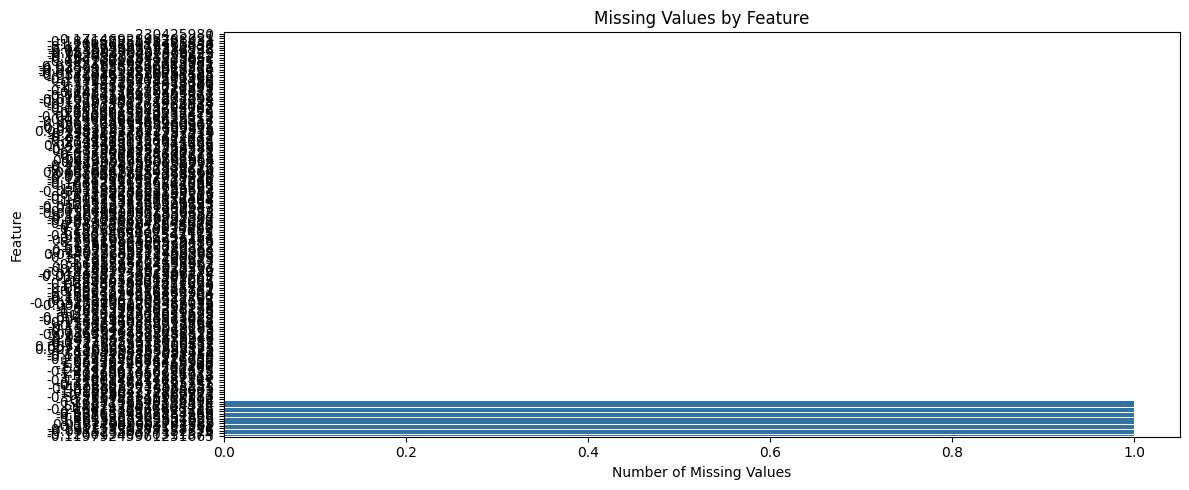

In [17]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=missing_counts.values,
    y=missing_counts.index
)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

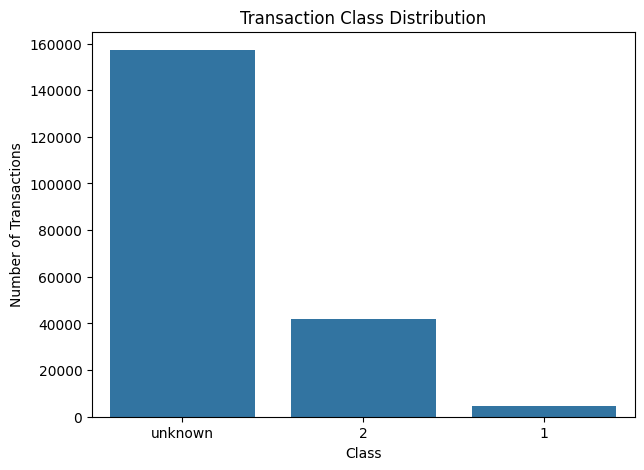

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=classes,
    x='class'
)

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

In [19]:
class_names = {
    '1': 'Illicit',
    '2': 'Licit',
    'unknown': 'Unknown'
}

classes_display = classes.copy()

classes_display['class_name'] = (
    classes_display['class']
    .astype(str)
    .map(class_names)
    .fillna(classes_display['class'].astype(str))
)

print(classes_display['class_name'].value_counts())

class_name
Unknown    157205
Licit       42019
Illicit      4545
Name: count, dtype: int64


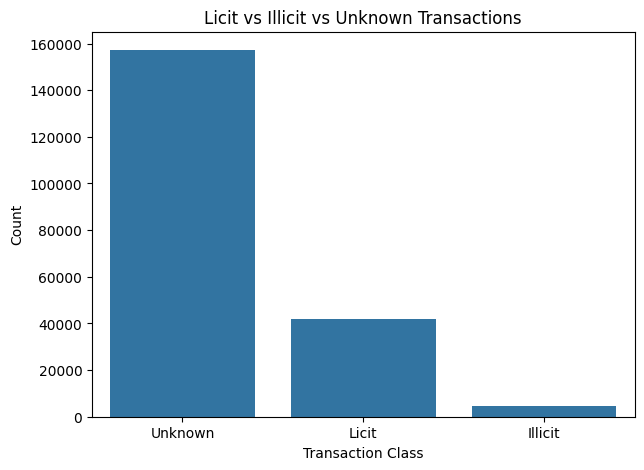

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=classes_display,
    x='class_name'
)

plt.title("Licit vs Illicit vs Unknown Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.show()

In [21]:
selected_features = [
    features_sample.columns[2],
    features_sample.columns[3],
    features_sample.columns[4],
    features_sample.columns[5],
    features_sample.columns[6],
    features_sample.columns[7]
]

print("Selected features:")
print(selected_features)

Selected features:
['-0.1714692896288031', '-0.18466755143291433', '-1.2013688016765636', '-0.12196959975910057', '-0.04387454791734898', '-0.11300200928476244']


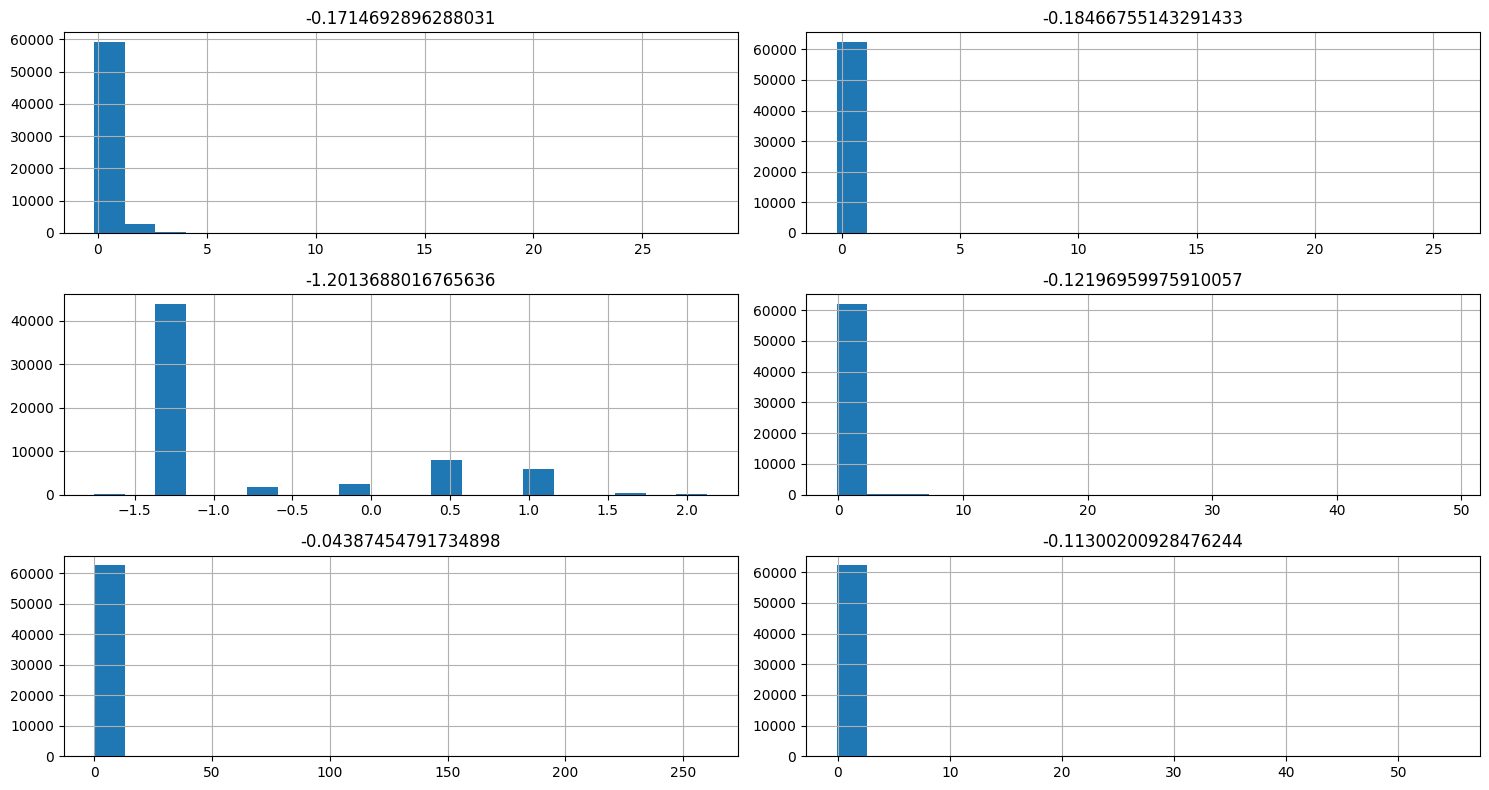

In [22]:
hist_data = pd.read_csv(
    '/content/elliptic_txs_features.csv',
    usecols=selected_features,
    nrows=100000
)

hist_data.hist(
    bins=20,
    figsize=(15, 8)
)

plt.tight_layout()
plt.show()

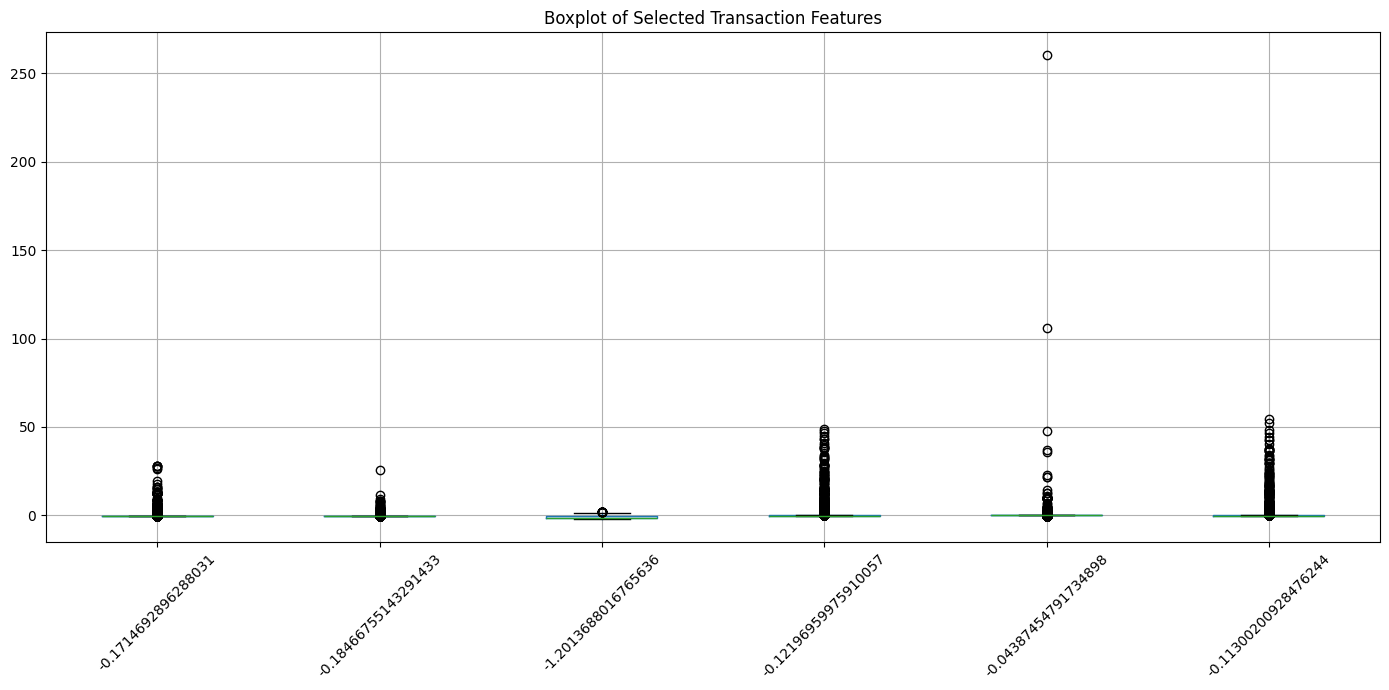

In [23]:
plt.figure(figsize=(14, 7))

hist_data.boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot of Selected Transaction Features")
plt.tight_layout()
plt.show()

In [24]:
corr_matrix = hist_data.corr()

print("--- Correlation Matrix ---")
print(corr_matrix)

--- Correlation Matrix ---
                      -0.1714692896288031  -0.18466755143291433  \
-0.1714692896288031              1.000000              0.028488   
-0.18466755143291433             0.028488              1.000000   
-1.2013688016765636             -0.043130              0.124946   
-0.12196959975910057             0.001254              0.628821   
-0.04387454791734898             0.037114              0.056504   
-0.11300200928476244             0.001638              0.606791   

                      -1.2013688016765636  -0.12196959975910057  \
-0.1714692896288031             -0.043130              0.001254   
-0.18466755143291433             0.124946              0.628821   
-1.2013688016765636              1.000000              0.140226   
-0.12196959975910057             0.140226              1.000000   
-0.04387454791734898             0.031599              0.002889   
-0.11300200928476244             0.147501              0.951249   

                      -0.04387454

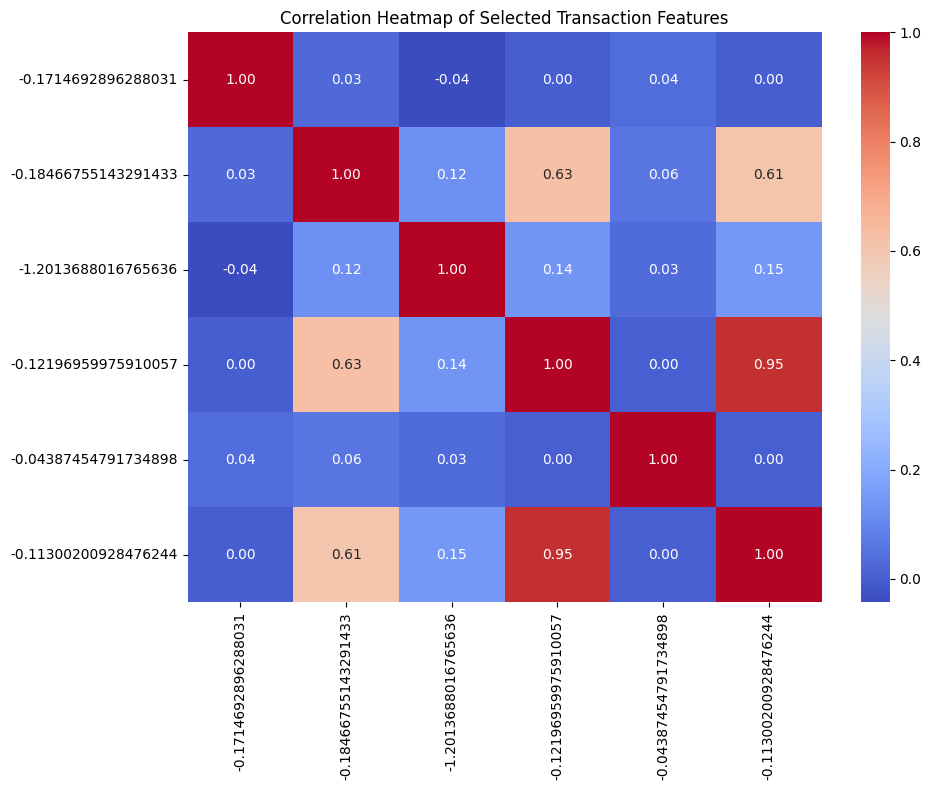

In [25]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Selected Transaction Features")
plt.tight_layout()
plt.show()

In [26]:
print("Total edges:", len(edges))
print("Columns:", edges.columns.tolist())

Total edges: 234355
Columns: ['txId1', 'txId2']


In [27]:
print("Unique source transactions:",
      edges.iloc[:, 0].nunique())

print("Unique destination transactions:",
      edges.iloc[:, 1].nunique())

Unique source transactions: 166345
Unique destination transactions: 148447


In [28]:
source_counts = edges.iloc[:, 0].value_counts()
destination_counts = edges.iloc[:, 1].value_counts()

print("Average outgoing connections:",
      source_counts.mean())

print("Average incoming connections:",
      destination_counts.mean())

Average outgoing connections: 1.4088490787219334
Average incoming connections: 1.578711594036929


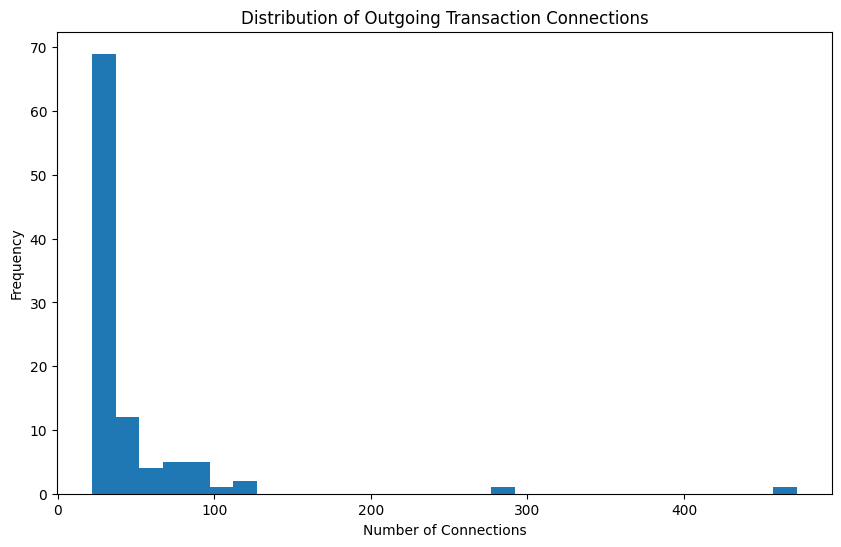

In [29]:
plt.figure(figsize=(10, 6))

source_counts.head(100).plot(
    kind='hist',
    bins=30
)

plt.title("Distribution of Outgoing Transaction Connections")
plt.xlabel("Number of Connections")
plt.ylabel("Frequency")
plt.show()

In [30]:
print("========== EDA SUMMARY ==========")

print("Feature rows:", row_count)
print("Feature columns:", len(features_sample.columns))

print("Class rows:", len(classes))
print("Edge count:", len(edges))

print("\nClass Distribution:")
print(classes['class'].value_counts())

print("\nTotal Missing Feature Values:",
      int(missing_counts.sum()))

print("\nEDA completed successfully!")

========== EDA SUMMARY ==========
Feature rows: 44950
Feature columns: 167
Class rows: 203769
Edge count: 234355

Class Distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

Total Missing Feature Values: 15

EDA completed successfully!
